In [24]:
import gc 
import matplotlib.pyplot as plt 
plt.style.use('ggplot')
import polars as pl
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.offline
import pandas as pd
from colorama import Fore, Style, init

import pyarrow as pa
import datetime as dt
import torch

from tqdm import tqdm
tqdm.pandas()

from pyarrow.parquet import ParquetFile
from datetime import datetime as dts
from pandarallel import pandarallel 
pandarallel.initialize(progress_bar=True)


import warnings
warnings.filterwarnings('ignore')


INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


In [25]:
def scale(X):
    from sklearn import preprocessing
    scaler = preprocessing.StandardScaler().fit(X)
    return (scaler.transform(X))

In [26]:
df = pd.read_csv('data/final_series_df.csv')

In [27]:
from sklearn.model_selection import train_test_split
X=df[['sd_anglez_1','sd_enmo_1','anglez','m_anglez_2','m_enmo_2','enmo','cluster']]
y=df[['sleep']]
X_scaled=scale(X)
X_train, X_test, y_train, y_test =train_test_split(X_scaled,y,test_size=0.2, random_state=42)


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate(y_test, ypred):
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    import seaborn as sns
    import matplotlib.pyplot as plt

    print("Accuracy: ", accuracy_score(y_test, ypred)) 
    print("Precision Score : ", precision_score(y_test, ypred)) 
    print("Recall Score: ", recall_score(y_test, ypred, average='macro')) 
    print("F1 Score: ", f1_score(y_test, ypred)) 

    cm = confusion_matrix(y_test, ypred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()






def evaluate_train_data(y_train, train_pred):
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    import seaborn as sns
    import matplotlib.pyplot as plt

    print("Accuracy: ", accuracy_score(y_train, train_pred)) 
    print("Precision Score : ", precision_score(y_train, train_pred)) 
    print("Recall Score: ", recall_score(y_train, train_pred, average='macro')) 
    print("F1 Score: ", f1_score(y_train, train_pred)) 

    cm = confusion_matrix(y_train, train_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()




In [29]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Set GPU parameters for speed
model = xgb.XGBClassifier(
    tree_method='hist', 
    device='cuda',             # Use GPU
    objective='multi:softmax',    # For classification
    random_state=42,
    num_class=2,          # Number of classes
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)



Accuracy:  0.8828750548147667
Precision Score :  0.8941217263604471
Recall Score:  0.8759789558644029
F1 Score:  0.8587323819504981


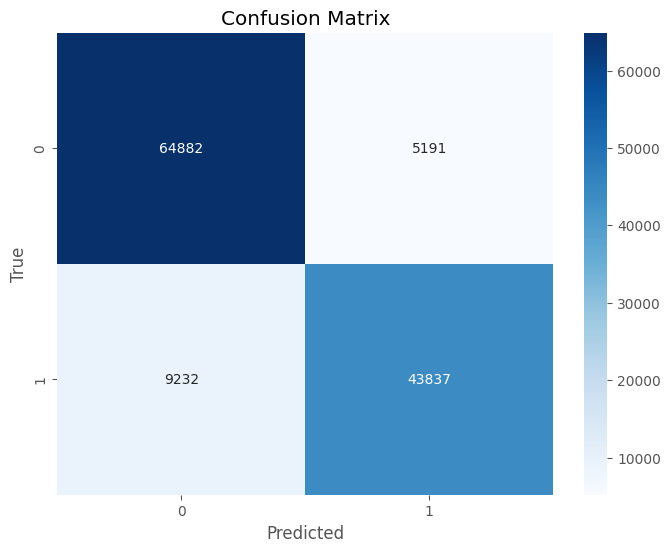

In [30]:
evaluate(y_test, y_pred)

Accuracy:  0.8878650011064485
Precision Score :  0.9006750339559441
Recall Score:  0.8809901224961898
F1 Score:  0.8646271941649061


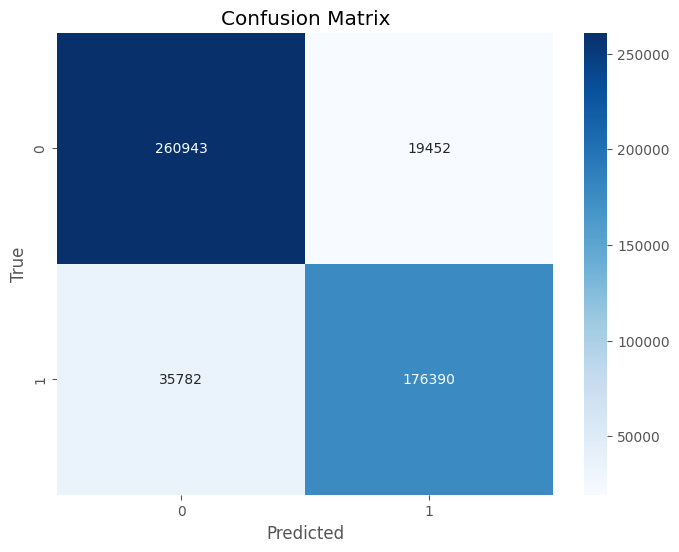

In [31]:
train_pred = model.predict(X_train)

evaluate_train_data(y_train, train_pred)

In [32]:
from sklearn.metrics import accuracy_score

def check_model_fit(train_acc, test_acc):
    print(f"\n Train Accuracy: {train_acc:.4f}")
    print(f" Test Accuracy:  {test_acc:.4f}")
    if train_acc > 0.95 and (train_acc - test_acc) > 0.1:
        print(" Model is likely OVERFITTING.")
    elif train_acc < 0.70 and test_acc < 0.70:
        print(" Model is likely UNDERFITTING.")
    else:
        print(" Model is likely a GOOD FIT.")
check_model_fit(
    train_acc=accuracy_score(y_train, train_pred),
    test_acc=accuracy_score(y_test, y_pred)
)


 Train Accuracy: 0.8879
 Test Accuracy:  0.8829
 Model is likely a GOOD FIT.


In [33]:
from joblib import dump, load
dump(model, 'Xgb_model.joblib')

['Xgb_model.joblib']

In [34]:
# load the saved model
XGB = load('Xgb_model.joblib')

In [36]:
XGB.predict(X_test) 

array([0, 0, 1, ..., 0, 0, 0])

# hyperparameter tunnig XGBoost

In [38]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Base model
model = xgb.XGBClassifier(
    device='cuda',            
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)

# Reduced hyperparameter space
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,             
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


In [39]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constra...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 1.0],
                                        'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [3, 6, 9],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.7, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [40]:
# Best model and predictions
best_XGB_model = random_search.best_estimator_
y_pred = best_XGB_model.predict(X_test)

# Evaluation
print("Best Hyperparameters:")
print(random_search.best_params_)
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

Best Hyperparameters:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Accuracy on Test Set: 0.9064088613145799


In [41]:

best_XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

Accuracy:  0.9064088613145799
Precision Score :  0.9217151210004872
Recall Score:  0.9002308474112106
F1 Score:  0.8873686782311263


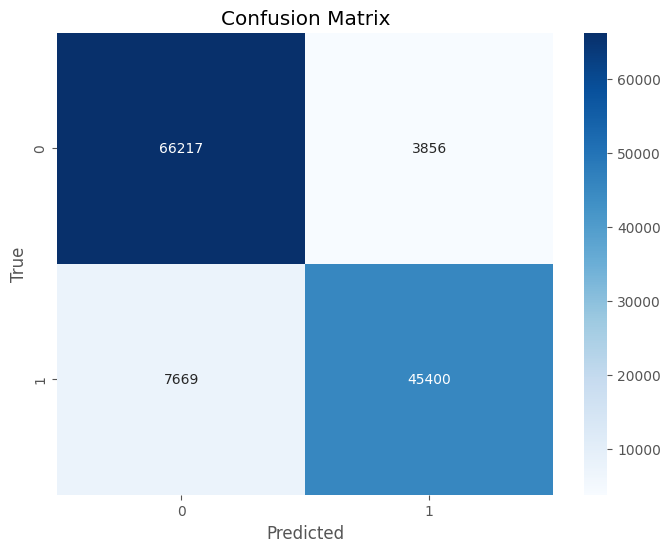

Accuracy:  0.9273032907198412
Precision Score :  0.9456832677981178
Recall Score:  0.9217777466330692
F1 Score:  0.9126698046484404


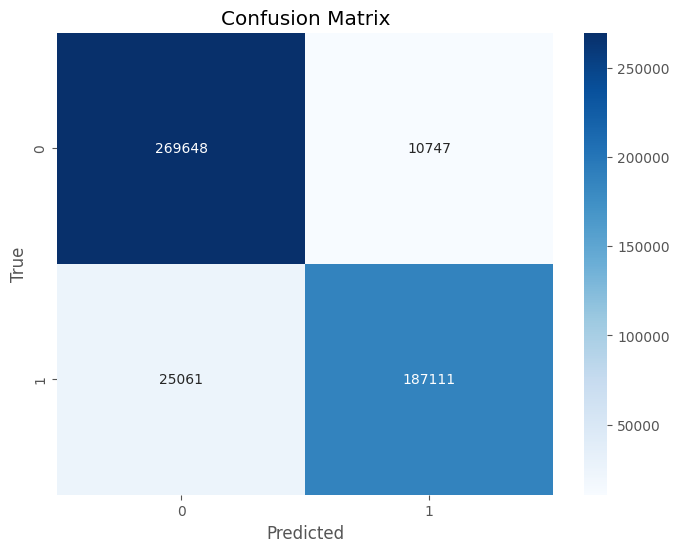

In [42]:
evaluate(y_test, y_pred)
evaluate_train_data(y_train, best_XGB_model.predict(X_train))

In [43]:
train_pred = best_XGB_model.predict(X_train)
test_pred = best_XGB_model.predict(X_test)
check_model_fit(
    train_acc=accuracy_score(y_train, train_pred),
    test_acc=accuracy_score(y_test, test_pred)
)


 Train Accuracy: 0.9273
 Test Accuracy:  0.9064
 Model is likely a GOOD FIT.


In [44]:
from joblib import dump, load
dump(best_XGB_model, 'XGB_tunned_model.joblib')

['XGB_tunned_model.joblib']

In [45]:
tuned_xgb = load('XGB_tunned_model.joblib')
tuned_xgb.predict(X_test)

array([0, 0, 1, ..., 0, 0, 0])

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model
model = RandomForestClassifier(random_state=42)

# Reduced hyperparameter space
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Randomized search setup
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,             
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
# Best model and predictions
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Hyperparameters:")
print(random_search.best_params_)
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

Best Hyperparameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Accuracy on Test Set: 0.9393464455669065


Accuracy:  0.9393464455669065
Precision Score :  0.9604014377448407
Recall Score:  0.9341127462518739
F1 Score:  0.9271963427591114


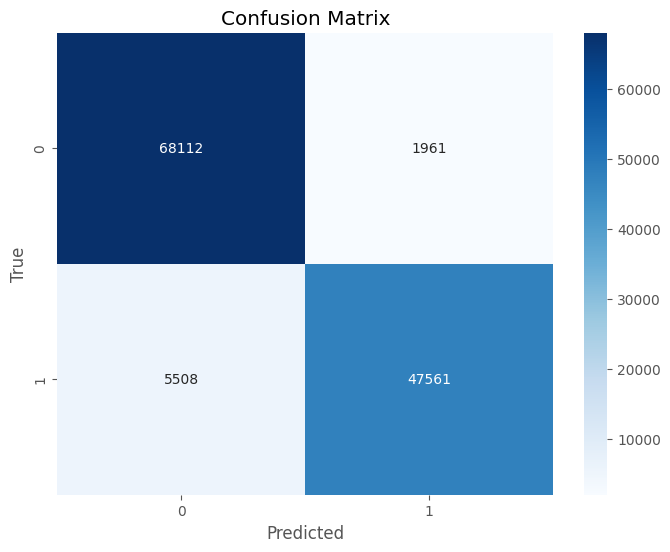

Accuracy:  0.9998193139207459
Precision Score :  0.9995807048869081
Recall Score:  0.999841295315537
F1 Score:  0.9997903084821397


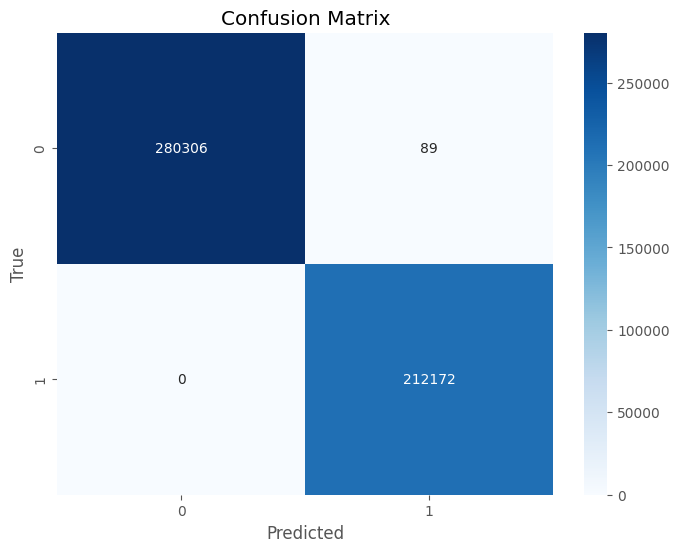

In [ ]:
best_model.fit(X_train, y_train)
evaluate(y_test, y_pred)
evaluate_train_data(y_train, best_model.predict(X_train))

In [ ]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)
check_model_fit(
    train_acc=accuracy_score(y_train, train_pred),
    test_acc=accuracy_score(y_test, test_pred)
)


 Train Accuracy: 0.9998
 Test Accuracy:  0.9393
 Model is likely a GOOD FIT.


In [ ]:
from joblib import load
from sklearn.preprocessing import scale
import pandas as pd


# Load and prepare new data
df = pd.read_csv('data/final_series_df.csv')
dd = df[df['sleep'] == 1].head(10)[['sd_anglez_1','sd_enmo_1','anglez','m_anglez_2','m_enmo_2','enmo','cluster']]
dy = df[df['sleep'] == 1].head(10)[['sleep']]
# Apply same scaling (only if you used it before training)


model = load('rf_tunned_model.joblib')

scaled_dd = scale(dd)

model.fit(dd, dy)

# Predict
predictions = model.predict(scaled_dd)
print(predictions)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [3]:
import pandas as pd
df  = pd.read_csv('data/final_series_df.csv')

a = df.sample(10000, random_state=42)

In [7]:
a['sleep'].value_counts()
a.to_csv('data/sample_data.csv', index=False)